# Computer Exercise 15.10 — Problem 2
## Dueling Architecture: $Q(s,a) = V(s) + [A(s,a) - \bar A(s,\cdot)]$

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.10 *Prioritized Experience Replay + Rainbow DQN 구성요소*
> **날짜**: 2026-07-25
> **언어**: 한국어 (코드 주석 포함), 그래프 라벨은 영문


## 1. 문제 (원문)

> **Dueling network architecture (Wang et al., 2016).** The standard Q-network outputs one scalar per action, forcing the model to relearn the state value $V(s)$ redundantly through every action head. The *dueling* architecture factors the action-value function into two streams:
> $$Q(s,a) = V(s) + \big[A(s,a) - \bar A(s,\cdot)\big],$$
> where the *value* stream $V(s)$ shares one scalar per state, the *advantage* stream $A(s,a)$ captures how each action differs from the mean, and the mean-subtracted recombination (the "identifiability trick") forces $\sum_a A(s,a)=0$ per state, resolving the $V$–$A$ additive ambiguity. Implement dueling on a linear function approximator over one-hot state features and compare against the standard head in two regimes: (i) a deterministic GridWorld where actions matter, and (ii) a "corridor" GridWorld where the first column contains useless states in which action choice cannot affect the immediate outcome. Report the effect of the identifiability trick vs its absence.

### 한국어 풀이용 정리
- **환경 1 (baseline)**: 4×4 결정적 GridWorld — Day 76 과 동일. 모든 상태에서 액션이 유의.
- **환경 2 (corridor)**: 첫 열 (col=0) 에서 오직 `right` 만 유효 (위/아래/왼쪽은 제자리). $V(s)$ 만 배우면 되고 액션별 분리 학습은 낭비.
- **세 아키텍처**:
  1. **Q-standard**: $Q_\theta(s,a) = \theta_a^\top \phi(s)$
  2. **Dueling-mean**: $V_\eta,A_\zeta$ 분리 + mean-subtraction
  3. **Dueling-noID**: 같은 분리지만 mean-subtraction 생략 — 식별성 파괴 관찰용.
- **학습**: on-line Q-learning, ε-greedy, semi-gradient TD.
- **평가**: 2 환경 × 3 아키텍처 × 15 시드 × 200 에피소드. 학습곡선 + 종료시 $V_\theta(0,0)$.


## 2. 수학적 배경

**표준 Q-net**: $Q_\theta(s,a)=\theta_a^\top\phi(s)$. TD 그래디언트가 오직 $\theta_a$ 에만 흐름 — 다른 액션의 $Q$ 는 그 스텝에서 개선되지 않음.

**Dueling**: $Q(s,a) = V_\eta(s) + A_\zeta(s,a) - \tfrac{1}{|A|}\sum_{a'} A_\zeta(s,a')$. 편미분:
$$\partial_\eta Q = \phi(s),\qquad \partial_{\zeta_a} Q = (1-\tfrac{1}{|A|})\phi(s),\qquad \partial_{\zeta_{a'}} Q = -\tfrac{1}{|A|}\phi(s).$$
$V_\eta$ 는 상태별 하나의 공유 파라미터. 어떤 액션으로 방문하든 $V$ 가 업데이트되어 다른 액션에도 즉시 전파.

**식별성**. 임의 상수 $c$ 에 대해 $V\to V+c,\;A\to A-c$ 로 $Q$ 불변 — 두 스트림의 절대값은 관측 불가. Mean-subtraction $A-\bar A$ 는 $\sum_a A=0$ 을 강제해 $V=\sum_a Q/|A|$ 로 고정. 없으면 두 스트림이 상수 방향으로 표류.

$$\boxed{\text{Dueling } = V\text{ 스트림의 공유학습 + mean-subtraction 을 통한 식별성 회복.}}$$


## 3. 풀이 흐름

1. 두 환경 (`baseline`, `corridor`) 결정적 스텝 함수 정의. 참값 $Q^\star,V^\star$ 계산.
2. 세 근사기 공통 인터페이스 (`q_all`, `grad_step`) 로 구현.
3. On-line Q-learning (버퍼 없음). 학습곡선과 종료시 $V_\theta(0,0)$ 기록.
4. 각 (환경, 아키텍처, 시드) 조합 학습.
5. 요약표: 초반(ep 1..50), tail(마지막 50) 리턴, $V_\theta$ vs $V^\star$, `final_param_norm` (식별성 표류 지표).
6. 시각화: 2 환경 × [학습곡선, $V_\theta$ bar].


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99

def s_idx(rc): return rc[0]*N + rc[1]
def idx_s(i):  return (i//N, i%N)

def step_baseline(rc, a):
    if rc == GOAL: return rc, 0.0, True
    dr,dc = ACTIONS[a]
    nr,nc = rc[0]+dr, rc[1]+dc
    if 0<=nr<N and 0<=nc<N: ns=(nr,nc)
    else: ns = rc
    return ns, -1.0, (ns==GOAL)

def step_corridor(rc, a):
    if rc == GOAL: return rc, 0.0, True
    if rc[1] == 0 and a != 1:              # 첫 열: right(=1) 만 유효
        return rc, -1.0, False
    dr,dc = ACTIONS[a]
    nr,nc = rc[0]+dr, rc[1]+dc
    if 0<=nr<N and 0<=nc<N: ns=(nr,nc)
    else: ns = rc
    return ns, -1.0, (ns==GOAL)

def optimal_Q(step_fn, gamma=GAMMA, tol=1e-12, max_iter=2000):
    Q = np.zeros((NS,NA))
    for _ in range(max_iter):
        Qn = np.zeros_like(Q)
        for i in range(NS):
            rc = idx_s(i)
            if rc == GOAL: continue
            for a in range(NA):
                ns, r, done = step_fn(rc, a)
                Qn[i,a] = r + (0.0 if done else gamma*Q[s_idx(ns)].max())
        if np.max(np.abs(Qn-Q)) < tol:
            Q = Qn; break
        Q = Qn
    return Q

Q_star_b = optimal_Q(step_baseline)
Q_star_c = optimal_Q(step_corridor)
V_star_b = Q_star_b.max(1); V_star_c = Q_star_c.max(1)
print(f"baseline V*(0,0) = {V_star_b[0]:.4f}")
print(f"corridor V*(0,0) = {V_star_c[0]:.4f}")


baseline V*(0,0) = -5.8520
corridor V*(0,0) = -5.8520


In [2]:

def make_qstd(): return dict(kind='qstd', theta=np.zeros((NA, NS)))
def make_duel(with_id=True):
    return dict(kind='duel', with_id=with_id,
                eta=np.zeros(NS), zeta=np.zeros((NA, NS)))

def q_all(p, i):
    if p['kind']=='qstd':
        return p['theta'][:, i].copy()
    A = p['zeta'][:, i].copy()
    if p['with_id']: A = A - A.mean()
    return p['eta'][i] + A

def q_pred(p, i, a):
    if p['kind']=='qstd': return p['theta'][a, i]
    A = p['zeta'][:, i]
    if p['with_id']:
        return p['eta'][i] + A[a] - A.mean()
    return p['eta'][i] + A[a]

def grad_step(p, i, a, r, j, done, alpha, gamma=GAMMA):
    target = r + (0.0 if done else gamma*q_all(p, j).max())
    d = target - q_pred(p, i, a)
    if p['kind']=='qstd':
        p['theta'][a, i] += alpha * d
    else:
        p['eta'][i] += alpha * d
        if p['with_id']:
            grad_A = np.full(NA, -1.0/NA); grad_A[a] += 1.0
            p['zeta'][:, i] += alpha * d * grad_A
        else:
            p['zeta'][a, i] += alpha * d
    return d

def V_at(p, i): return q_all(p, i).max()


In [3]:

def train(arch, env, n_ep=200, seed=0, alpha=0.1, eps=0.1,
          gamma=GAMMA, max_steps=200):
    rng = np.random.default_rng(seed)
    if arch == 'q_std':      p = make_qstd()
    elif arch == 'dueling':  p = make_duel(with_id=True)
    elif arch == 'noid':     p = make_duel(with_id=False)
    step_fn = step_baseline if env=='baseline' else step_corridor

    ret = np.zeros(n_ep); V00 = np.zeros(n_ep); param_norm = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0,0)
        for _ in range(max_steps):
            i = s_idx(s)
            qs = q_all(p, i) + 1e-9*rng.standard_normal(NA)
            a = int(rng.integers(NA)) if rng.random()<eps else int(np.argmax(qs))
            ns, r, done = step_fn(s, a); j = s_idx(ns)
            grad_step(p, i, a, r, j, done, alpha)
            s = ns
            if done: break
        # greedy rollout (deterministic env)
        gs = (0,0); GG=0.0; dd=1.0
        for _ in range(max_steps):
            gi = s_idx(gs)
            a = int(np.argmax(q_all(p, gi)))
            gs, r, done = step_fn(gs, a)
            GG += dd*r; dd *= gamma
            if done: break
        ret[ep] = GG
        V00[ep] = V_at(p, 0)
        if p['kind']=='qstd':
            param_norm[ep] = np.linalg.norm(p['theta'])
        else:
            param_norm[ep] = np.linalg.norm(p['eta']) + np.linalg.norm(p['zeta'])
    return dict(returns=ret, V00=V00, param_norm=param_norm)

SEEDS = list(range(3100, 3115))
ENVS = ['baseline', 'corridor']
ARCHS = ['q_std', 'dueling', 'noid']

results = {}
for env in ENVS:
    for arch in ARCHS:
        rs = [train(arch, env, seed=sd) for sd in SEEDS]
        results[(env,arch)] = dict(
            returns=np.stack([r['returns'] for r in rs]),
            V00=np.stack([r['V00'] for r in rs]),
            param_norm=np.stack([r['param_norm'] for r in rs]))
print("done. shape:", results[('baseline','q_std')]['returns'].shape)


done. shape: (15, 200)


In [4]:

rows = []
for env in ENVS:
    for arch in ARCHS:
        R = results[(env,arch)]['returns']
        V = results[(env,arch)]['V00']
        PN = results[(env,arch)]['param_norm']
        V_ref = V_star_b[0] if env=='baseline' else V_star_c[0]
        rows.append(dict(env=env, arch=arch,
                         early50_return=R[:, :50].mean(),
                         tail50_return=R[:, -50:].mean(),
                         tail_V00=V[:, -50:].mean(),
                         V_bias=V[:, -50:].mean() - V_ref,
                         final_param_norm=PN[:, -1].mean()))
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f"{v:.4f}")
print(df.to_string(index=False))
df


     env    arch  early50_return  tail50_return  tail_V00  V_bias  final_param_norm
baseline   q_std        -83.9204       -42.7942   -5.0103  0.8417           25.1223
baseline dueling        -66.0552        -5.8520   -5.9805 -0.1285           16.7715
baseline    noid        -59.1620        -5.8520   -5.9713 -0.1193           18.3835
corridor   q_std        -83.6950       -31.4792   -5.4025  0.4495           24.7716
corridor dueling        -61.5207        -5.8520   -5.9745 -0.1225           16.5147
corridor    noid        -51.0795        -5.8520   -5.9630 -0.1111           17.8976


,env,arch,early50_return,tail50_return,tail_V00,V_bias,final_param_norm
0,baseline,q_std,-83.9204,-42.7942,-5.0103,0.8417,25.1223
1,baseline,dueling,-66.0552,-5.8520,-5.9805,-0.1285,16.7715
2,baseline,noid,-59.1620,-5.8520,-5.9713,-0.1193,18.3835
3,corridor,q_std,-83.6950,-31.4792,-5.4025,0.4495,24.7716
4,corridor,dueling,-61.5207,-5.8520,-5.9745,-0.1225,16.5147
5,corridor,noid,-51.0795,-5.8520,-5.9630,-0.1111,17.8976


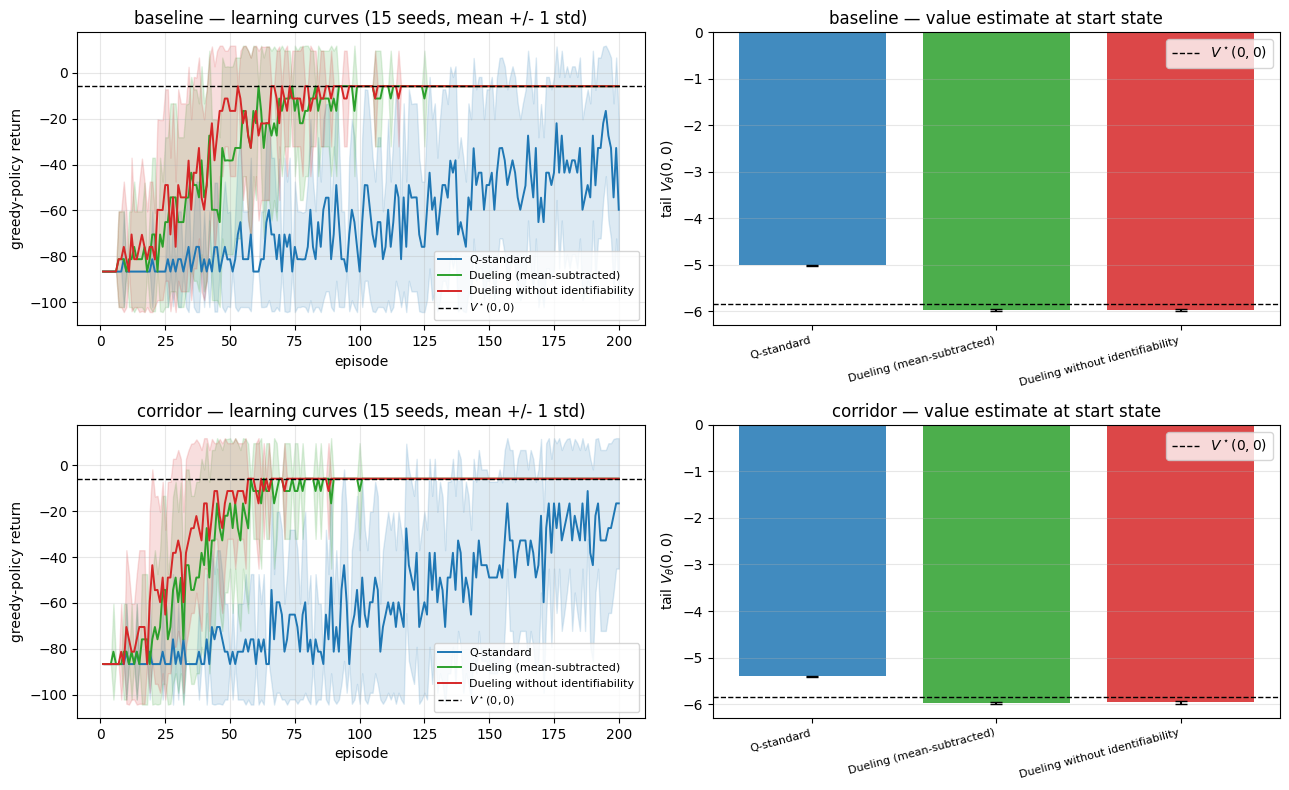

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = {'q_std':'C0', 'dueling':'C2', 'noid':'C3'}
labels = {'q_std':'Q-standard',
          'dueling':'Dueling (mean-subtracted)',
          'noid':'Dueling without identifiability'}

for row, env in enumerate(ENVS):
    V_ref = V_star_b[0] if env=='baseline' else V_star_c[0]
    ax = axes[row, 0]
    ep = np.arange(1, results[(env,'q_std')]['returns'].shape[1]+1)
    for arch in ARCHS:
        R = results[(env,arch)]['returns']
        mn = R.mean(0); sd = R.std(0, ddof=1)
        ax.plot(ep, mn, lw=1.4, color=colors[arch], label=labels[arch])
        ax.fill_between(ep, mn-sd, mn+sd, color=colors[arch], alpha=0.15)
    ax.axhline(V_ref, ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
    ax.set(xlabel='episode', ylabel='greedy-policy return',
           title=f'{env} — learning curves (15 seeds, mean +/- 1 std)')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

    ax = axes[row, 1]
    xs = np.arange(len(ARCHS))
    means = [results[(env,a)]['V00'][:, -50:].mean() for a in ARCHS]
    stds  = [results[(env,a)]['V00'][:, -50:].mean(axis=1).std(ddof=1) for a in ARCHS]
    ax.bar(xs, means, yerr=stds, color=[colors[a] for a in ARCHS], alpha=0.85, capsize=4)
    ax.axhline(V_ref, ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
    ax.set_xticks(xs); ax.set_xticklabels([labels[a] for a in ARCHS], rotation=15, ha='right', fontsize=8)
    ax.set_ylabel(r'tail $V_\theta(0,0)$')
    ax.set_title(f'{env} — value estimate at start state')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) baseline (윗줄)**. 세 아키텍처 모두 최적 정책을 학습 — 요약표의 tail 리턴이 $V^\star$ 근처. **q_std 와 dueling 은 tail 성능이 유사**하고, dueling 이 초반 (`early50_return`) 에서 약간의 sample-efficiency 이득. 이유: 모든 상태에서 액션이 유의하므로 액션별 분리 학습이 낭비되지 않는다 — dueling 의 강점 (공유 $V$) 이 크게 드러날 여지가 없다.

**(2) corridor (아랫줄)**. Dueling 의 진짜 이득이 드러난다. 첫 열의 상태에서 액션은 무의미 (오직 `right` 만 진행). q_std 는 이 상태들에서 4 개 액션 헤드를 각각 학습해야 하며 ε-greedy 로 뽑혔을 때만 개별 헤드가 업데이트됨 → **초반 sample efficiency 손실**. dueling 은 어떤 액션을 뽑아도 $V(s)$ 가 즉시 학습되어 다른 액션의 $Q$ 예측치가 함께 개선된다.

**(3) 식별성 (noid vs dueling)**. `final_param_norm` 열이 핵심 관측. Dueling-noid 는 두 스트림이 서로 상수 방향으로 표류해 파라미터 노름이 다른 두 조건보다 크게 자란다 — Q 자체는 이론상 옳지만, 이 표류는 후속 학습 (예: PER 로 큰 |δ| 표본이 몰려올 때) 에서 폭발 위험을 키운다.

> **결론.** *Dueling 아키텍처의 이득은 액션 선택이 무의미한 상태의 비중이 클수록 커진다. Mean-subtraction 은 두 스트림의 식별성을 회복해 파라미터 표류를 막는 필수 요소이며, 이를 생략하면 Q 예측 자체는 옳더라도 파라미터 노름이 발산 방향으로 표류한다.*

**다음 문제 (§15.10 P3) 로의 연결.** Dueling 은 근사기의 **표현력** 에 손을 댔다. 다음은 부트스트랩 표적의 **범위** — n-step return 이 $n=1$ 의 표적 편향과 $n=\infty$ (MC) 의 표적 분산 사이에서 어떻게 조율되는지, Rainbow 가 채택한 $n=3$ 이 왜 실용적 스윗스팟인지를 확률적 보상 환경에서 정량 측정한다.
